# 图表反演

In [7]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

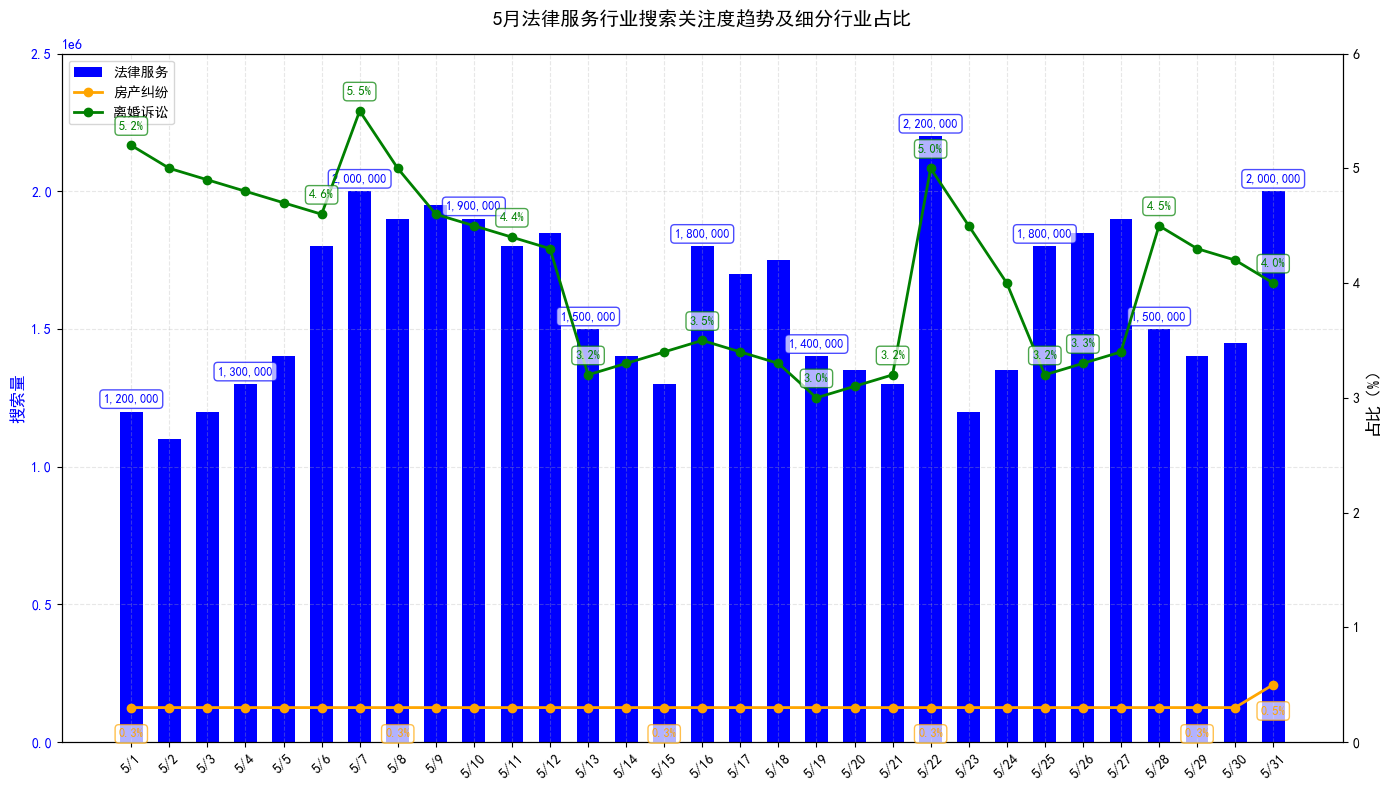

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 日期列表
dates = ["5/1", "5/2", "5/3", "5/4", "5/5", "5/6", "5/7", "5/8", "5/9", "5/10", 
         "5/11", "5/12", "5/13", "5/14", "5/15", "5/16", "5/17", "5/18", "5/19", 
         "5/20", "5/21", "5/22", "5/23", "5/24", "5/25", "5/26", "5/27", "5/28", 
         "5/29", "5/30", "5/31"]
# 法律服务搜索量（柱状，左轴）
legal_service = [1200000, 1100000, 1200000, 1300000, 1400000, 1800000, 2000000, 
                 1900000, 1950000, 1900000, 1800000, 1850000, 1500000, 
                 1400000, 1300000, 1800000, 1700000, 1750000, 1400000, 
                 1350000, 1300000, 2200000, 1200000, 1350000, 1800000, 
                 1850000, 1900000, 1500000, 1400000, 1450000, 2000000]
# 房产纠纷占比（近似%）列表
property_dispute = [0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 
                    0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 
                    0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.5]
# 离婚诉讼占比（近似%）列表
divorce_lawsuit = [5.2, 5.0, 4.9, 4.8, 4.7, 4.6, 5.5, 5.0, 4.6, 4.5, 
                   4.4, 4.3, 3.2, 3.3, 3.4, 3.5, 3.4, 3.3, 3.0, 3.1, 
                   3.2, 5.0, 4.5, 4.0, 3.2, 3.3, 3.4, 4.5, 4.3, 4.2, 4.0]

# 创建画布与双轴
fig, ax1 = plt.subplots(figsize=(14, 8))  # 主轴（左轴）
ax2 = ax1.twinx()  # 次轴（右轴，占比）

# 绘制法律服务（柱状图，左轴）
x = np.arange(len(dates))  # 横坐标索引
bars = ax1.bar(x, legal_service, color='blue', label='法律服务', width=0.6)
ax1.set_ylabel('搜索量', color='blue', fontsize=12)
ax1.set_ylim(0, 2500000)  # 匹配原图左轴范围
ax1.tick_params(axis='y', labelcolor='blue')

# 绘制房产纠纷、离婚诉讼（折线图，右轴）
line1, = ax2.plot(x, property_dispute, color='orange', label='房产纠纷', marker='o', linestyle='-', linewidth=2)
line2, = ax2.plot(x, divorce_lawsuit, color='green', label='离婚诉讼', marker='o', linestyle='-', linewidth=2)
ax2.set_ylabel('占比（%）', color='black', fontsize=12)
ax2.set_ylim(0, 6)  # 匹配原图右轴范围（0%-6%）
ax2.tick_params(axis='y', labelcolor='black')

# 横坐标与图例设置
ax1.set_xticks(x)
ax1.set_xticklabels(dates, rotation=45, fontsize=10)  # 倾斜日期避免重叠
ax1.set_title('5月法律服务行业搜索关注度趋势及细分行业占比', fontsize=14, pad=20)

# 为柱状图添加数据标注（搜索量）
for i, bar in enumerate(bars):
    height = bar.get_height()
    # 每隔3天显示一次标注，避免过于密集
    if i % 3 == 0:
        ax1.annotate(f'{height:,}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # 向上偏移5点
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9,
                    color='blue',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.7))

# 为房产纠纷折线图添加数据标注
for i, (x_val, y_val) in enumerate(zip(x, property_dispute)):
    # 只标注有变化的点和关键节点
    if y_val != 0.3 or i % 7 == 0 or i == len(x)-1:
        ax2.annotate(f'{y_val}%',
                    xy=(x_val, y_val),
                    xytext=(0, -15),  # 向下偏移
                    textcoords="offset points",
                    ha='center', va='top',
                    fontsize=9,
                    color='orange',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="orange", alpha=0.7))

# 为离婚诉讼折线图添加数据标注
for i, (x_val, y_val) in enumerate(zip(x, divorce_lawsuit)):
    # 只标注峰值、谷值和关键节点
    if i == 0 or i == len(x)-1 or i % 5 == 0 or \
       (i > 0 and i < len(x)-1 and 
        (y_val > divorce_lawsuit[i-1] and y_val > divorce_lawsuit[i+1]) or 
        (y_val < divorce_lawsuit[i-1] and y_val < divorce_lawsuit[i+1])):
        ax2.annotate(f'{y_val}%',
                    xy=(x_val, y_val),
                    xytext=(0, 10),  # 向上偏移
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9,
                    color='green',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.7))

# 合并图例（双轴图例统一展示）
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

# 添加网格线提高可读性
ax1.grid(True, linestyle='--', alpha=0.3)

# 优化布局
plt.tight_layout()
plt.show()

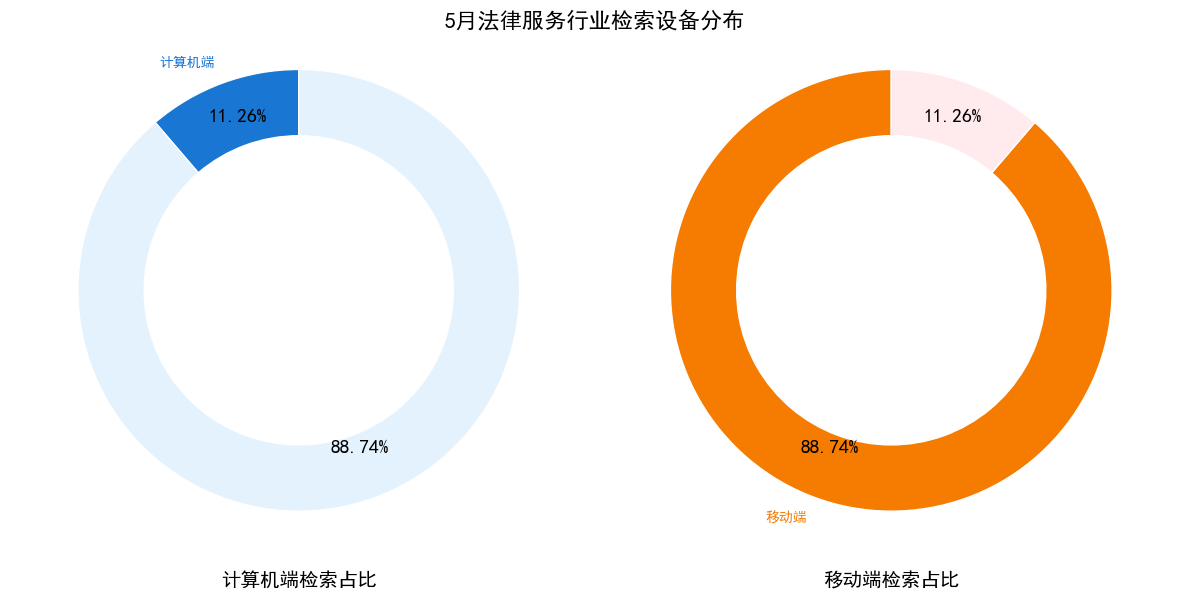

In [9]:
import matplotlib.pyplot as plt

# 数据
sizes = [11.26, 88.74]

# 颜色，更接近原图
computer_colors = ["#1976d2", "#e3f2fd"]  # 计算机端颜色：深蓝色和浅蓝色
mobile_colors = ["#f57c00", "#ffebee"]    # 移动端颜色：橙色和浅橙色

# 创建画布和两个子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(top=0.85, bottom=0.15)  # 调整顶部和底部边距

# 绘制计算机端检索占比图（标签颜色调整）
wedges1, texts1, autotexts1 = ax1.pie(
    [sizes[0], 100 - sizes[0]],
    labels=["计算机端", ""],  # 简化标签
    autopct=lambda p: f'{p:.2f}%\n' if p >= 3 else '',
    startangle=90,
    pctdistance=0.8,
    colors=computer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# 绘制移动端检索占比图（标签颜色调整）
wedges2, texts2, autotexts2 = ax2.pie(
    [sizes[1], 100 - sizes[1]],
    labels=["移动端", ""],  # 简化标签
    autopct=lambda p: f'{p:.2f}%\n' if p >= 3 else '',
    startangle=90,
    pctdistance=0.8,
    colors=mobile_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# 设置标签颜色（与对应饼图颜色一致）
for text in texts1:
    text.set_color(computer_colors[0])  # 计算机端标签颜色为深蓝色
for text in texts2:
    text.set_color(mobile_colors[0])    # 移动端标签颜色为深橙色

# 设置百分比文本颜色为黑色
for text in autotexts1 + autotexts2:
    text.set_color('black')
    text.set_fontsize(14)

# 去除坐标轴，使图表为正圆形
ax1.axis('equal')
ax2.axis('equal')

# 设置小标题（在图表下方）
ax1.text(0.5, -0.1, "计算机端检索占比", 
         ha='center', va='center', transform=ax1.transAxes, fontsize=14)
ax2.text(0.5, -0.1, "移动端检索占比", 
         ha='center', va='center', transform=ax2.transAxes, fontsize=14)

# 设置总标题
fig.suptitle("5月法律服务行业检索设备分布", fontsize=16, fontweight='bold')

plt.tight_layout()  # 调整布局，避免重叠
plt.show()

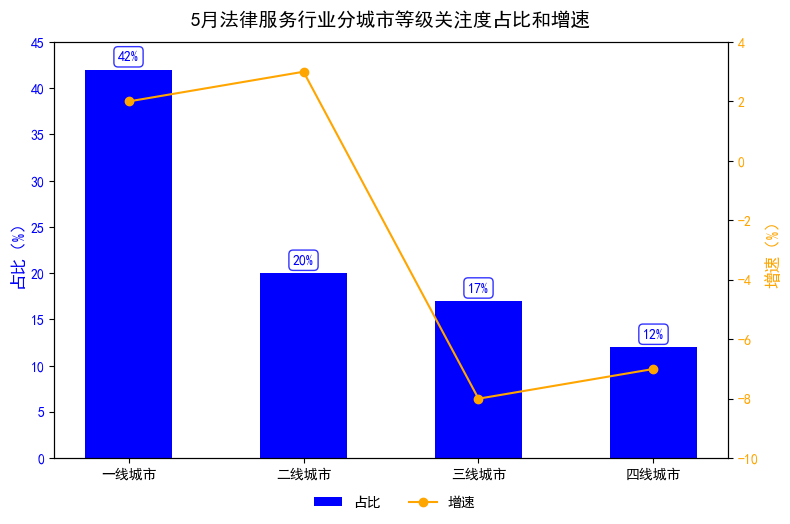

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
categories = ["一线城市", "二线城市", "三线城市", "四线城市"]
percentages = [42, 20, 17, 12]  # 占比数据
growth_rates = [2, 3, -8, -7]   # 增速数据

# 创建画布和双Y坐标轴
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# 绘制占比柱状图
x = np.arange(len(categories))
bars = ax1.bar(
    x, percentages, 
    color="blue", 
    width=0.5, 
    label="占比"
)
ax1.set_ylabel("占比（%）", fontsize=12, color="blue")
ax1.set_ylim(0, 45)
ax1.tick_params(axis="y", labelcolor="blue")

# 绘制增速折线图
ax2.plot(
    x, growth_rates, 
    color="orange", 
    marker="o", 
    label="增速"
)
ax2.set_ylabel("增速（%）", fontsize=12, color="orange")
ax2.set_ylim(-10, 4)
ax2.tick_params(axis="y", labelcolor="orange")

# 设置X轴刻度和标签
ax1.set_xticks(x)
ax1.set_xticklabels(categories)

# 设置标题
plt.title("5月法律服务行业分城市等级关注度占比和增速", fontsize=14, y=1.02)

# 为柱状图添加占比数据标注（仅保留条形数据标注）
for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f'{height}%',  # 显示百分比符号
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),  # 向上偏移5个点，避免与柱顶重叠
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=10,
        color='blue',  # 与柱状图同色，增强关联性
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.8)  # 白色背景框突出显示
    )

# 调整图例位置到图表下方
fig.legend(
    loc="lower center", 
    bbox_to_anchor=(0.5, -0.05),
    ncol=2, 
    frameon=False
)

# 优化布局
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()

# 显示图表
plt.show()

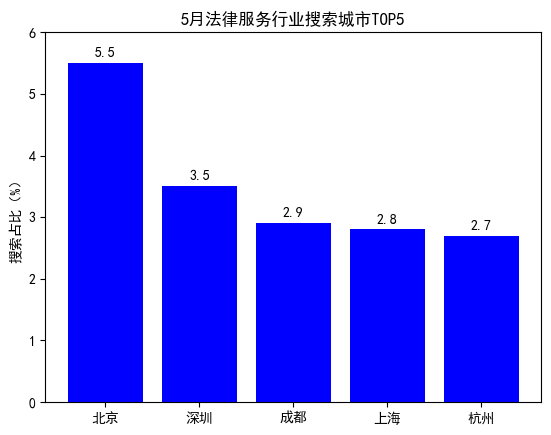

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 城市名称
cities = ['北京', '深圳', '成都', '上海', '杭州']
# 各城市对应的搜索占比（基于图表估算，你可替换为精确数据）
percentages = [5.5, 3.5, 2.9, 2.8, 2.7]  

x = np.arange(len(cities))  # x轴坐标

fig, ax = plt.subplots()
# 绘制柱状图，设置柱子颜色为蓝色
rects = ax.bar(x, percentages, color='blue')  

# 设置x轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(cities)
# 设置y轴范围
ax.set_ylim([0, 6])  
# 设置y轴刻度
ax.set_yticks(np.arange(0, 7, 1))  
# 添加图表标题
ax.set_title('5月法律服务行业搜索城市TOP5')  
# 添加y轴标签
ax.set_ylabel('搜索占比（%）')  

# 在柱子上标注数值（可选，让图表信息更直观）
for rect in rects:
    height = rect.get_height()
    ax.annotate('{}'.format(height),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 数值标注距离柱子的垂直距离
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()